September 25 - Load in Microns dataset, understand it, and plot same ROI traces over time

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 359.8/359.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.7/336.7 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.1/753.1 kB 52.4 MB/s eta 0:00:00
   ━━━━━

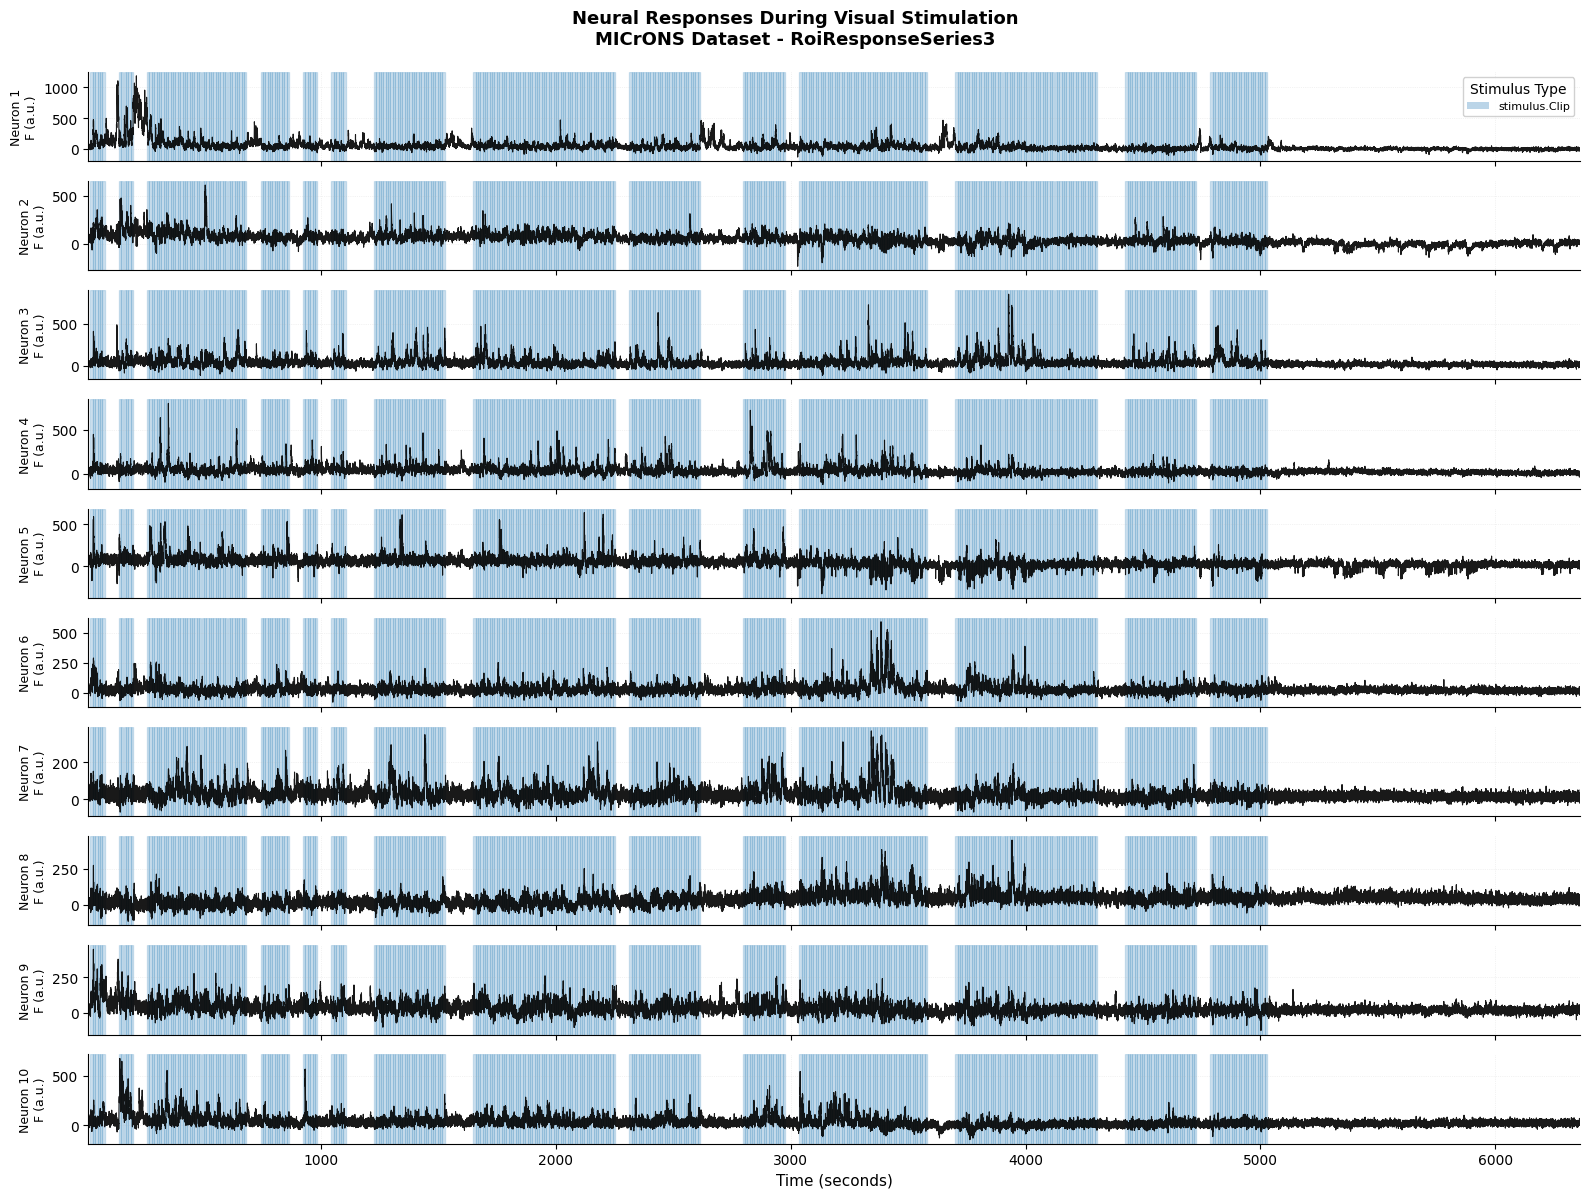

oki dat it lols


In [1]:

# MICrONS Neural Response Visualization
# This notebook retrieves calcium imaging data from the MICrONS dataset
# and visualizes neural responses during visual stimulation experiments

# Install required packages for streaming data from DANDI Archive
!pip install -q dandi remfile pynwb h5py

import numpy as np
import matplotlib.pyplot as plt
import requests
import remfile
import h5py
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient

# ============================================================================
# CONNECT TO DATASET
# ============================================================================
# DANDI (Distributed Archives for Neurophysiology Data Integration) hosts
# large-scale neuroscience datasets. Rather than downloading the entire file
# (which exceeds 50 GB), we can stream the data directly from cloud storage.
print("\n" + "="*70)
print("CONNECTING TO MICRONS DATASET")
print("="*70)

DANDISET = "000402"  # MICrONS functional imaging dataset identifier

# Establish connection to DANDI API and retrieve dataset information
client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET, "draft")

# Get all assets from the dataset
all_assets = dandiset.get_assets()

# Find the first NWB file
asset = None
for a in all_assets:
    if a.path.endswith(".nwb"):
        asset = a
        break

print(f"Asset: {asset.path}")

# Obtain the S3 URL for the file stored in cloud storage
s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

# Check the remote file size
head = requests.head(s3_url, allow_redirects=True)
size_bytes = int(head.headers.get("Content-Length", 0))
size_gb = size_bytes / (1024 * 1024 * 1024)
print(f"File size: {size_gb:.2f} GB")

# Open the remote file for streaming access
# remfile enables streaming of data chunks without downloading the entire file
rf = remfile.File(s3_url)
h5 = h5py.File(rf, "r")  # HDF5 is the underlying format for NWB files
io = NWBHDF5IO(file=h5, load_namespaces=True)
nwb = io.read()  # NWB (Neurodata Without Borders) is the standardized format

print("Yay connected :p")

# ============================================================================
# EXTRACT FLUORESCENCE DATA
# ============================================================================
# Calcium imaging data is stored in the optical physiology (ophys) module.
# When neurons fire action potentials, calcium ions enter the cell, causing
# fluorescent indicators to emit light. Higher fluorescence indicates increased
# neural activity.
print("\n" + "="*70)
print("LOADING FLUORESCENCE DATA")
print("="*70)

ophys = nwb.processing["ophys"]
fluorescence = ophys.data_interfaces["Fluorescence"]

# The dataset contains multiple imaging planes (different cortical depths).
# Each plane contains different neurons, identified as ROIs (Regions of Interest).
PLANE = "RoiResponseSeries3"  # Modify this variable to examine different planes
rs = fluorescence.roi_response_series[PLANE]

# Get the shape of the data
data_shape = rs.data.shape
total_neurons = data_shape[1]
total_timepoints = data_shape[0]

print(f"\nSelected plane: {PLANE}")
print(f"  Total neurons: {total_neurons}")
print(f"  Total timepoints: {total_timepoints}")

# Configuration parameters
N_ROIS = 10  # Number of neurons to visualize

# Calculate how many timepoints to use
if 40000 < total_timepoints:
    N_TIMEPOINTS = 40000
else:
    N_TIMEPOINTS = total_timepoints

# Stream the fluorescence data from cloud storage
print(f"\nStreaming {N_TIMEPOINTS} timepoints × {N_ROIS} neurons")

# Get the data as a numpy array
# Original data shape is (time, neurons)
fluorescence_data_raw = np.asarray(rs.data[:N_TIMEPOINTS, :N_ROIS], dtype=np.float32)

# Transpose to (neurons, time) for easier plotting
fluorescence_data = fluorescence_data_raw.T

# Get the timestamps for each sample
timestamps = np.array(rs.timestamps[:N_TIMEPOINTS])


# ============================================================================
# EXTRACT STIMULUS INFORMATION
# ============================================================================
# During recording, various visual stimuli were presented to the subject.
# Stimulus timing and metadata are stored in interval tables.
print("\n" + "="*70)
print("LOADING STIMULUS INFORMATION")
print("="*70)

# Get the clip intervals table
clip_intervals = nwb.intervals['Clip']

# Extract stimulus timing and information
clip_starts = np.array(clip_intervals.start_time[:])
clip_stops = np.array(clip_intervals.stop_time[:])
clip_names = np.array(clip_intervals.short_movie_name[:])
clip_types = np.array(clip_intervals.stimulus_type[:])

print(f"\nStimulus presentations: {len(clip_starts)}")

# Get unique stimulus types
unique_types = np.unique(clip_types)
print(f"Stimulus types: {list(unique_types)}")

# Identify stimuli that fall within the current temporal window
# Check each stimulus to see if it overlaps with our viewing window
first_time = timestamps[0]
last_time = timestamps[-1]

in_window = []
for i in range(len(clip_starts)):
    start = clip_starts[i]
    stop = clip_stops[i]
    if start < last_time and stop > first_time:
        in_window.append(True)
    else:
        in_window.append(False)

in_window = np.array(in_window)

# Count how many of each stimulus type are in the window
print(f"\nStimuli in current time window:")
for stim_type in unique_types:
    count = 0
    for i in range(len(clip_types)):
        if in_window[i] and clip_types[i] == stim_type:
            count = count + 1
    print(f"  • {stim_type}: {count} presentations")

# Display specific clips present in the viewing window
print(f"\nSpecific clips in this window:")
clip_counter = 0
for i in range(len(clip_starts)):
    if in_window[i]:
        if clip_counter < 15:  # Limit output to first 15 entries
            start = clip_starts[i]
            stop = clip_stops[i]
            name = clip_names[i]
            stype = clip_types[i]
            # Truncate name if too long
            if len(name) > 40:
                name_display = name[:40]
            else:
                name_display = name
            print(f"  {start:6.1f}s - {stop:6.1f}s: {name_display} ({stype})")
        clip_counter = clip_counter + 1

total_in_window = np.sum(in_window)
if total_in_window > 15:
    print(f"  ... and {total_in_window - 15} more")

# ============================================================================
# VISUALIZATION: INDIVIDUAL TRACES WITH STIMULUS BLOCKS
# ============================================================================
# Generate plots showing neural activity traces with stimulus timing overlaid.
# Each neuron is displayed in a separate subplot for clarity.
print("\n" + "="*70)
print("VISUALIZATION OF TRACES")
print("="*70)

# Create figure with vertically stacked subplots
fig, axes = plt.subplots(N_ROIS, 1, figsize=(16, 12), sharex=True)

# Handle case where there's only one subplot
if N_ROIS == 1:
    axes = [axes]

# Assign distinct colors to each stimulus type for visual differentiation
unique_stim_types = np.unique(clip_types)
stim_colors = {}
for i in range(len(unique_stim_types)):
    stim = unique_stim_types[i]
    color_index = i % 10  # Use modulo to cycle through 10 colors
    stim_colors[stim] = plt.cm.tab10(color_index)

# Plot fluorescence trace for each neuron
for roi_idx in range(N_ROIS):
    ax = axes[roi_idx]

    # Extract fluorescence time series for this neuron
    trace = fluorescence_data[roi_idx, :]

    # Plot the fluorescence trace in black
    ax.plot(timestamps, trace, 'k', linewidth=0.8, alpha=0.9)

    # Overlay colored regions indicating stimulus presentation periods
    for stim_idx in range(len(clip_starts)):
        start = clip_starts[stim_idx]
        stop = clip_stops[stim_idx]
        stim_type = clip_types[stim_idx]
        name = clip_names[stim_idx]

        # Only render stimuli within the current viewing window
        if start < last_time and stop > first_time:
            # Get the color for this stimulus type
            color = stim_colors[stim_type]

            # Draw a shaded rectangle
            ax.axvspan(start, stop, alpha=0.2, color=color, zorder=0)

            # Add text labels to the first subplot only to avoid clutter
            if roi_idx == 0:
                duration = stop - start
                # Only label sufficiently long stimuli
                if duration > 50:
                    # Center the label horizontally
                    mid = (start + stop) / 2

                    # Truncate lengthy stimulus names
                    if len(name) > 20:
                        name_display = name[:20]
                    else:
                        name_display = name

                    # Get current y-axis limits
                    ylim = ax.get_ylim()
                    y_position = ylim[1] * 0.95

                    # Add the text
                    ax.text(mid, y_position, name_display,
                           ha='center', va='top',
                           fontsize=7, rotation=0,
                           bbox=dict(boxstyle='round,pad=0.3',
                                    facecolor='white',
                                    alpha=0.7,
                                    edgecolor='none'))

    # Format subplot: remove unnecessary spines and add grid
    ax.set_ylabel(f'Neuron {roi_idx+1}\nF (a.u.)', fontsize=9)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

# Configure x-axis (temporal axis) on the bottom subplot
axes[-1].set_xlabel('Time (seconds)', fontsize=11)
axes[-1].set_xlim(first_time, last_time)

# Add figure title
fig.suptitle(f'Neural Responses During Visual Stimulation\nMICrONS Dataset - {PLANE}',
             fontsize=13, fontweight='bold', y=0.995)

# Create legend showing stimulus type color coding
legend_elements = []
for stim in unique_stim_types:
    color = stim_colors[stim]
    rect = plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.3, label=stim)
    legend_elements.append(rect)

axes[0].legend(handles=legend_elements,
              loc='upper right',
              fontsize=8,
              framealpha=0.9,
              title='Stimulus Type')

plt.tight_layout()
plt.show()

print(f"oki dat it lols")

In [2]:
# Install required packages for accessing the data
!pip install -q dandi remfile pynwb h5py

import numpy as np
import pandas as pd
import requests
import remfile
import h5py
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient

print("="*80)
print("CONNECTING TO MICRONS DATASET")
print("="*80)

# Define the dataset identifier
DANDISET = "000402"

# Connect to DANDI API
client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET, "draft")

# Find the first NWB file in the dataset
all_assets = dandiset.get_assets()
asset = None
for a in all_assets:
    if a.path.endswith(".nwb"):
        asset = a
        break

print(f"Asset: {asset.path}\n")

# Get the URL where the file is stored
s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

# Open the file for streaming
rf = remfile.File(s3_url)
h5 = h5py.File(rf, "r")
io = NWBHDF5IO(file=h5, load_namespaces=True)
nwb = io.read()

# ============================================================================
# SESSION INFORMATION
# ============================================================================
# This section displays basic information about the recording session
# and the experimental subject (the mouse)
print("="*80)
print("SESSION INFORMATION")
print("="*80)

print(f"\nSubject:")
print(f"  ID: {nwb.subject.subject_id}")
print(f"  Species: {nwb.subject.species}")
print(f"  Sex: {nwb.subject.sex}")
print(f"  Age: {nwb.subject.age}")

# ============================================================================
# DATA ACQUISITION MODULES
# ============================================================================
# Data acquisition modules contain the raw recorded data from various instruments.
# This shows what types of measurements were made during the experiment.
print("\n" + "="*80)
print("DATA ACQUISITION MODULES")
print("="*80)

# Count how many acquisition modules are present
num_modules = len(nwb.acquisition)
print(f"\nTotal acquisition modules: {num_modules}\n")

# Loop through each acquisition module and display its information
acquisition_keys = list(nwb.acquisition.keys())
for key in acquisition_keys:
    item = nwb.acquisition[key]
    print(f"  • {key}")

    # Get the type name of this module
    type_name = type(item).__name__
    print(f"    Type: {type_name}")

    # If the module has a description, print it
    if hasattr(item, 'description'):
        print(f"    Description: {item.description}")

# ============================================================================
# PROCESSING MODULES
# ============================================================================
# Processing modules contain data that has been processed or analyzed
# after the initial acquisition (e.g., extracted neural signals)
print("\n" + "="*80)
print("PROCESSING MODULES")
print("="*80)

# Get list of all processing modules
processing_keys = list(nwb.processing.keys())
print(f"\nAvailable processing modules: {processing_keys}\n")

# Check if the optical physiology module exists
if 'ophys' in nwb.processing:
    ophys = nwb.processing['ophys']
    print(f"Optical Physiology Module Contents:")

    # Loop through each data interface in the ophys module
    interface_keys = list(ophys.data_interfaces.keys())
    for key in interface_keys:
        print(f"  • {key}")
        item = ophys.data_interfaces[key]
        type_name = type(item).__name__
        print(f"    Type: {type_name}")

# ============================================================================
# FLUORESCENCE DATA STRUCTURE
# ============================================================================
# This section examines the structure of the calcium imaging data.
# The fluorescence data is organized into different imaging planes,
# where each plane represents a different depth in the brain.
print("\n" + "="*80)
print("FLUORESCENCE DATA STRUCTURE")
print("="*80)

# Access the fluorescence data interface
fluorescence = nwb.processing["ophys"].data_interfaces["Fluorescence"]

print(f"\nAvailable imaging planes (RoiResponseSeries):\n")

# Loop through each imaging plane
series_keys = list(fluorescence.roi_response_series.keys())
for key in series_keys:
    rs = fluorescence.roi_response_series[key]

    print(f"  • {key}")

    # Get the shape of the data (time × neurons)
    data_shape = rs.data.shape
    print(f"    Shape: {data_shape} (time × ROIs)")

    # Extract dimensions
    num_neurons = data_shape[1]
    num_timepoints = data_shape[0]
    print(f"    Number of neurons/ROIs: {num_neurons}")
    print(f"    Number of timepoints: {num_timepoints}")

    # Calculate recording duration
    first_timestamp = rs.timestamps[0]
    last_timestamp = rs.timestamps[-1]
    duration = last_timestamp - first_timestamp
    print(f"    Duration: {duration:.1f} seconds")

    # Calculate approximate sampling rate
    # Take first 1000 timestamps to calculate time differences
    timestamps_subset = rs.timestamps[:1000]
    time_diffs = np.diff(timestamps_subset)
    median_diff = np.median(time_diffs)
    sampling_rate = 1 / median_diff
    print(f"    Sampling rate: ~{sampling_rate:.2f} Hz")
    print()

# ============================================================================
# STIMULUS INTERVALS - DETAILED BREAKDOWN
# ============================================================================
# This section provides comprehensive information about the visual stimuli
# that were presented to the mouse during the recording.
print("="*80)
print("STIMULUS INFORMATION (INTERVALS)")
print("="*80)

# Check if the 'Clip' interval table exists
if 'Clip' in nwb.intervals:
    clip_intervals = nwb.intervals['Clip']

    # Display all column names in the clip intervals table
    print(f"\nClip Interval Columns:")
    for col in clip_intervals.colnames:
        print(f"  • {col}")

    # Convert the interval table to a pandas DataFrame for easier analysis
    clip_df = clip_intervals.to_dataframe()

    print(f"\n" + "="*80)
    print(f"TOTAL STIMULUS PRESENTATIONS: {len(clip_df)}")
    print("="*80)

    # Count how many presentations of each stimulus type
    print("\n--- STIMULUS TYPE BREAKDOWN ---")
    stim_counts = clip_df['stimulus_type'].value_counts()

    # Loop through each stimulus type and print the count
    for stim_type in stim_counts.index:
        count = stim_counts[stim_type]
        print(f"  {stim_type}: {count} presentations")

    # Count unique stimulus clips
    print(f"\n--- UNIQUE STIMULI ---")
    unique_movies = clip_df['short_movie_name'].unique()
    num_unique = len(unique_movies)
    print(f"Total unique movie clips: {num_unique}\n")

    # Display a timeline of stimulus presentations
    print(f"\n{'='*80}")
    print("STIMULUS PRESENTATION TIMELINE (First 20)")
    print('='*80)

    # Print header for the table
    print(f"\n{'#':<4} {'Start':<8} {'Stop':<8} {'Duration':<10} {'Type':<15} {'Clip Name'}")
    print("-"*80)

    # Determine how many rows to display (maximum 20)
    num_clips = len(clip_df)
    if num_clips < 20:
        rows_to_show = num_clips
    else:
        rows_to_show = 20

    # Loop through each row and display the information
    for i in range(rows_to_show):
        row = clip_df.iloc[i]

        # Calculate stimulus duration
        duration = row['stop_time'] - row['start_time']

        # Truncate long clip names to fit in the display
        clip_name = row['short_movie_name']
        if len(clip_name) > 30:
            clip_name_display = clip_name[:30]
        else:
            clip_name_display = clip_name

        # Print the row with formatted columns
        row_number = i + 1
        print(f"{row_number:<4} {row['start_time']:<8.1f} {row['stop_time']:<8.1f} {duration:<10.2f} {row['stimulus_type']:<15} {clip_name_display}")

    # If there are more than 20 clips, indicate how many more exist
    if num_clips > 20:
        remaining = num_clips - 20
        print(f"\n... and {remaining} more presentations")

    # Display a detailed table of the first 50 stimulus presentations
    print(f"\n{'='*80}")
    print("FULL STIMULUS TABLE (First 50 rows)")
    print('='*80)

    # Get first 50 rows (or all rows if less than 50)
    if len(clip_df) < 50:
        rows_to_display = len(clip_df)
    else:
        rows_to_display = 50

    table_subset = clip_df.head(rows_to_display)
    print(table_subset.to_string())

CONNECTING TO MICRONS DATASET
Asset: sub-17797/sub-17797_ses-4-scan-7_behavior+image+ophys.nwb

SESSION INFORMATION

Subject:
  ID: 17797
  Species: Mus musculus
  Sex: M
  Age: P75D/P81D

DATA ACQUISITION MODULES

Total acquisition modules: 12

  • EyeTracking
    Type: EyeTracking
  • PupilTracking
    Type: PupilTracking
  • TwoPhotonSeries1
    Type: TwoPhotonSeries
    Description: Calcium imaging data for field 1 at 6.3009 Hz and 8e-05 meters depth.
  • TwoPhotonSeries2
    Type: TwoPhotonSeries
    Description: Calcium imaging data for field 2 at 6.3009 Hz and 8e-05 meters depth.
  • TwoPhotonSeries3
    Type: TwoPhotonSeries
    Description: Calcium imaging data for field 3 at 6.3009 Hz and 0.00022 meters depth.
  • TwoPhotonSeries4
    Type: TwoPhotonSeries
    Description: Calcium imaging data for field 4 at 6.3009 Hz and 0.00022 meters depth.
  • TwoPhotonSeries5
    Type: TwoPhotonSeries
    Description: Calcium imaging data for field 5 at 6.3009 Hz and 0.00036 meters depth